In [1]:
import pandas as pd 
import numpy as np

In [2]:
closing_prices_df = pd.read_csv("./assets/closing_prices.csv",delimiter=';',index_col=0)
closing_prices_df.index = pd.to_datetime(closing_prices_df.index)

In [3]:
log_returns_pct = np.log(closing_prices_df).diff()*100
is_negotiable = log_returns_pct.isnull() == False

In [4]:
rolling_std = log_returns_pct.rolling(window=12).std()

<Axes: xlabel='close_time'>

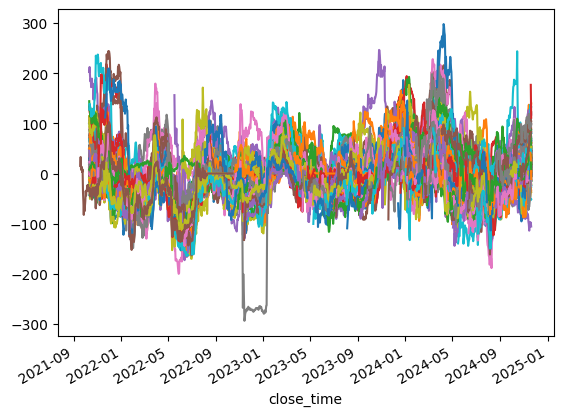

In [5]:
indicador_long_short = log_returns_pct.rolling(window=63).sum()
indicador_long_short.plot(legend=False)

In [6]:
minimo_numero_de_constituintes = 100
filtro_dias_negociaveis = (indicador_long_short.isnull() == False).sum(axis=1) > minimo_numero_de_constituintes

In [7]:
indicador_long_short = indicador_long_short.loc[filtro_dias_negociaveis]
stds_estimados = rolling_std.loc[filtro_dias_negociaveis]
log_returns_pct = log_returns_pct.loc[filtro_dias_negociaveis]

In [8]:
n_ativos = 14
shift_lags = 1

retornos = []
todos_os_dias = indicador_long_short.index[0:-shift_lags]
for index in todos_os_dias:
    indicador_do_dia = indicador_long_short.loc[index]
    std_do_dia = stds_estimados.loc[index]
    long = indicador_do_dia.sort_values().head(n_ativos)
    short = indicador_do_dia.sort_values(ascending=False).head(n_ativos)
    
    std_do_portfolio = pd.concat([std_do_dia[short.index],std_do_dia[long.index]])
    std_do_portfolio = std_do_portfolio.replace({0:std_do_portfolio.mean()})
    
    pesos_portfolio = (std_do_portfolio**-1/((std_do_portfolio**-1).sum()))
    pesos_portfolio = pesos_portfolio.loc[~pesos_portfolio.isnull()]

    retorno_do_dia = log_returns_pct.iloc[np.where(todos_os_dias==index)[0][0] + shift_lags]
    retorno_ponderado = (retorno_do_dia*pesos_portfolio).dropna()
    
    retorno_ponderado.loc[retorno_ponderado.index.isin(short.index)] = retorno_ponderado.loc[retorno_ponderado.index.isin(short.index)] *-1

    
    retorno_vol_weight = retorno_ponderado.sum()
    retorno_equal_weight = ((retorno_do_dia[long.index].mean() - (retorno_do_dia[short.index].mean()))/2)


    dic_retornos = {'index':index,
        'retorno_vol_weight':retorno_vol_weight,
     'retorno_equal_weight':retorno_equal_weight}
    retornos.append(dic_retornos)



In [9]:
df_retornos_estrategia = pd.DataFrame(retornos).set_index('index')

In [10]:
years = 252/(df_retornos_estrategia.index[-1] - df_retornos_estrategia.index[0]).days

In [11]:
np.exp(df_retornos_estrategia.cumsum()/100) -1

,retorno_vol_weight,retorno_equal_weight
index,,
2021-10-10 23:59:59.999,0.000097,-0.005437
2021-10-11 23:59:59.999,-0.010323,-0.014468
2021-10-12 23:59:59.999,0.005608,-0.000638
2021-10-13 23:59:59.999,0.021992,0.019477
2021-10-14 23:59:59.999,0.036404,0.045550
...,...,...
2024-11-14 23:59:59.999,1.311558,3.119790
2024-11-15 23:59:59.999,1.396335,3.253791
2024-11-16 23:59:59.999,1.317098,3.106571


In [12]:
3.188684 **(years) -1

0.2936448396598157

In [60]:
retorno_do_fundo = 6.79/100
custo = [0.1/100,0.15/100,0.2/100,0.25/100,0.3/100,0.5/100,1/100,2/100]

In [61]:
summary_custo_retorno = []
for c in custo:
    retorno_bruto = []
    retorno_af_cost = []
    for i in range(1,21):
        total_do_fundo = (1+retorno_do_fundo)**i
        retorno_af_adm_fee = total_do_fundo *(1-c)**i
        retorno_bruto.append(total_do_fundo)
        retorno_af_cost.append(retorno_af_adm_fee)
    summary_custo_retorno.append(retorno_af_cost)
    

In [62]:
curvas_de_custo = pd.DataFrame(summary_custo_retorno).T
curvas_de_custo.columns =[f"Taxa de adm {ele*100}% a.a" for ele in custo]
curvas_de_custo.index = (curvas_de_custo.index+1)

In [63]:
curvas_de_custo['Retorno Bruto'] = (1+retorno_do_fundo)**curvas_de_custo.index

In [ ]:
# Pouco se discute do papel de custos nos mercados financeiros. Sendo que ao que tudo indica custos podem ser bem previsiveis mesmo no longo prazo. 
# Eu falo de taxas de adiminstração, performance comissões e outros custos que um investidor irá pagar ao interagir com o mercado financeiro.
# Nesse post iremos tratar sobre como que as taxas de administração, custo incorrido no patrimonio do fundo sobre o valor custodiado por ele impacta nos retornos brutos
# Mostro o efeito de diversas taxas de adm em um investimento real de 5% a.a em média durante 20 anos
# os Resultados mostram que para taxas de adm de 1% a.a vc pagará ao gestor aproximadamente 0.18% dos seus retornos para taxas de 2% a.a pagase 1/3 dos retornos. Para etfs passivos com taxa de 0.25% ao ano paga-se 5% dos retornos aperoximadamente. Resultado muito menor 

<Axes: >

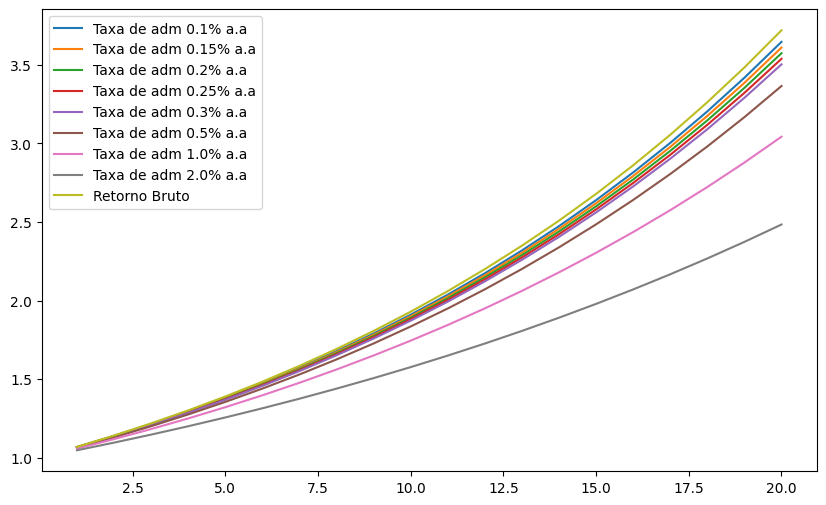

In [64]:
curvas_de_custo.plot(figsize=(10,6))

<Axes: >

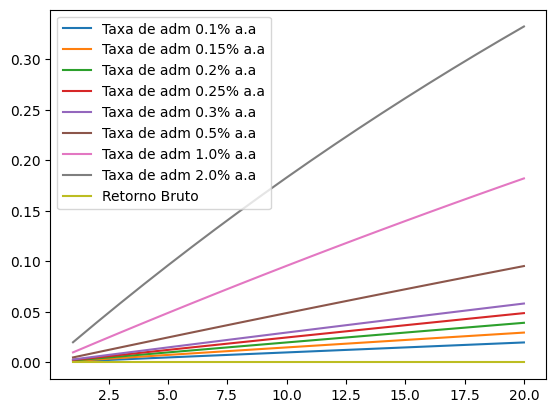

In [65]:
(1-curvas_de_custo.apply(lambda row : row/row['Retorno Bruto'],axis=1)).plot()

In [67]:
(1-curvas_de_custo.apply(lambda row : row/row['Retorno Bruto'],axis=1))

,Taxa de adm 0.1% a.a,Taxa de adm 0.15% a.a,Taxa de adm 0.2% a.a,Taxa de adm 0.25% a.a,Taxa de adm 0.3% a.a,Taxa de adm 0.5% a.a,Taxa de adm 1.0% a.a,Taxa de adm 2.0% a.a,Retorno Bruto
1,0.001000,0.001500,0.002000,0.002500,0.003000,0.005000,0.010000,0.020000,0.0
2,0.001999,0.002998,0.003996,0.004994,0.005991,0.009975,0.019900,0.039600,0.0
3,0.002997,0.004493,0.005988,0.007481,0.008973,0.014925,0.029701,0.058808,0.0
4,0.003994,0.005987,0.007976,0.009963,0.011946,0.019850,0.039404,0.077632,0.0
5,0.004990,0.007478,0.009960,0.012438,0.014910,0.024751,0.049010,0.096079,0.0
6,0.005985,0.008966,0.011940,0.014907,0.017866,0.029627,0.058520,0.114158,0.0
7,0.006979,0.010453,0.013916,0.017369,0.020812,0.034479,0.067935,0.131874,0.0
8,0.007972,0.011937,0.015888,0.019826,0.023750,0.039307,0.077255,0.149237,0.0
9,0.008964,0.013419,0.017857,0.022276,0.026678,0.044110,0.086483,0.166252,0.0
10,0.009955,0.014899,0.019821,0.024721,0.029598,0.048890,0.095618,0.182927,0.0
